<a href="https://colab.research.google.com/github/edwardtsai54398/Pneumonia_detection_model/blob/master/model/Pneumonia_detection_model_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

準備GPU

↓

從三個資料集準備 DataLoader
圖片資料轉換、加強

↓

類別對索引、定義正類

↓

建立初始模型 ───────── 替換 fc 層、凍結 backbone

↓

平衡「類別不平均」的加權

↓

建立 損失函式、優化器、排程器

↓

迴圈訓練

↓

優化器梯度歸零

模型預測

計算損失

反向傳播

更新參數

紀錄損失、精準度、召回率、F1 指標

紀錄表現最好的參數

↓

輸出最好的參數和模型資料

In [ ]:
import torch
from pathlib import Path
import numpy as np
from torchvision import datasets, transforms, models
import torch.nn as nn
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"使用裝置: {device}")

使用裝置: cuda


In [ ]:
# 資料集 DataLoader
import kagglehub

# 資料集檔案路徑
dataset_root = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")
dataset_root = Path(dataset_root)
dataset_root = dataset_root / "chest_xray"
print(dataset_root)

train_dir = dataset_root / "train"
val_dir = dataset_root / "val"
test_dir = dataset_root / "test"

for dir in [train_dir, val_dir, test_dir]:
        if not dir.exists():
            raise FileNotFoundError(f"資料夾不存在: {d}")
        else:
          print(dir)


# 圖片資料轉換、增強
img_size = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((256,256)), # 放大到256*256
    transforms.RandomResizedCrop(size=img_size, scale=(0.85, 1.0)), # 隨機裁切
    transforms.RandomRotation(degrees=7), # 隨機旋轉 7 度
    transforms.RandomHorizontalFlip(p=0.5), # 50% 的機率會水平翻轉
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD) # Note 1
])

val_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=3),
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

test_tf = val_tf


Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
/kaggle/input/chest-xray-pneumonia/chest_xray
/kaggle/input/chest-xray-pneumonia/chest_xray/train
/kaggle/input/chest-xray-pneumonia/chest_xray/val
/kaggle/input/chest-xray-pneumonia/chest_xray/test


## Note 1 -- Normalize 標準化
* 確保所有數值都在相同尺度內，避免某些像素值過大或過小而對模型訓練產生不利影響。
* 標準化後的數據可以使 梯度下降 更快找到模型最佳參數

## 為什麼「以 0 為中心」的資料對訓練很重要？

我知道反向傳播在計算 loss 對每個權重的梯度<然後用梯度去更新權重:
```
weight = weight - learning_rate * gradient
```
#### 關鍵:梯度的大小和 input 值有直接關係
對某一個 weight 的梯度來說，大概長這樣(簡化版):
```
gradient_of_weight = upstream_signal * input_value
```
upstream_signal 是靠近結果方向的神經元傳來的值
```
                   input_value       upstream_signal
                   (h 的值)          (loss 對 o 的梯度)
                      │                    │
                      ▼                    ▼
 ┌─────┐   w1    ┌─────┐   w2 ←目標  ┌─────┐
 │  x  │───────→│  h  │───────────→│  o  │←──── loss
 └─────┘        └─────┘          └─────┘
                                         │
                                    loss 對 o 的梯度
                                    (由 loss 直接算出)

 w2 的梯度 = upstream_signal * input_value
           = (loss對o的梯度) * h
```
所以

#### 沒有 Normalize (輸入是0.0~1.0)


```
input_value = [0.0, 0.5, 0.8]
upstream_signal = -0.3

gradient_of_weight = [0.0, -0.15, -0.24]
```
每個 weight 的梯度都是同一個方向，所有 weight 都會往同一個方向加大。為了讓 loss 變小，其實有些 weight 應該要增大、有些應該要減小。結果就是——這次更新讓某些 weight 矯正太過頭了，下一次反向傳播又發現梯度要反過來修正，就這樣來回擺盪，花很多步才能收斂。

#### 有 Normalize（輸入以 0 為中心，有正有負）
```
input_value = [-1.2, 0.3, -0.5]
upstream_signal = -0.3

gradient_of_weight = [0.36, -0.09, 0.15]
```
這次梯度有正有負，每個 weight 可以各自往最適合的方向調整。

In [ ]:
# 資料集 DataLoader


image_datasets = {
        "train": datasets.ImageFolder(root=str(train_dir), transform=train_tf),
        "val": datasets.ImageFolder(root=str(val_dir), transform=val_tf),
        "test": datasets.ImageFolder(root=str(test_dir), transform=test_tf),
    }
# 確保三個資料集的標籤順序一致
train_class_to_idx = image_datasets["train"].class_to_idx
for split in ["val", "test"]:
  if image_datasets[split].class_to_idx != train_class_to_idx:
    raise ValueError(f"{split} 的 class_to_idx 與 train 的不一致")

dataloaders = {
    split: DataLoader(image_datasets[split], batch_size=32, shuffle=(split == "train"), num_workers=2, pin_memory=torch.cuda.is_available())
    for split in ["train", "val", "test"]
}


In [ ]:
# 定義正類
num_classes = len(train_class_to_idx)
positive_index = train_class_to_idx.get("PNEUMONIA", 1)
print(f"類別: {train_class_to_idx}, 正類別索引(PNEUMONIA): {positive_index}")

類別: {'NORMAL': 0, 'PNEUMONIA': 1}, 正類別索引(PNEUMONIA): 1


In [ ]:
# 使用 EfficientNet_B3 作為遷移學習模型。Note 2
weights = models.EfficientNet_B3_Weights.IMAGENET1K_V1
model = models.efficientnet_b3(weights=weights)
in_feature = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_feature, num_classes)

model = model.to(device)

# freeze backbone
for name, param in model.named_parameters():
    if "classifier" not in name:
        # 如果 weights 是backbone 層，凍結權重更新
        param.requires_grad = False

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 189MB/s]


# Note 2 -- 為何選擇 EfficientNet_B3

參考資料--pytorch 預訓練模型列表:https://docs.pytorch.org/vision/stable/models.html#table-of-all-available-classification-weights

請 AI 整理預訓練模型表現前5名:
| 排名模型名稱(Weight 版本) | Top-1 Acc | GFLOPs (運算開銷) | Params(參數量) |
| --- | --- | --- | ---
| MobileNet_V3_Large | 75.27% | 0.22 | 5.5M |
| EfficientNet_B0 | 77.69% | 0.39 | 5.3M |
| EfficientNet_B3 | 82.00% | 1.83|12.2M|
| ConvNeXt_Tiny | 82.52% | 4.46 | 28.6M |
| ResNet50(V2 權重) | 80.85% | 4.09 | 25.5M |

由於診斷病症需要高的精準度，避免誤判或漏判，EfficientNet_B3 相比 ConvNeXt_Tiny 的精準度只低了約 0.5%，但運算開銷卻是 EfficientNet_B3 的 1/2 倍，工程角度來說， EfficientNet_B3 更有效率，更划算。故選擇 EfficientNet_B3。

In [ ]:
# 平衡「類別不平均」的加權(Note 3)
def compute_class_weights(dataset, num_classes, device):
  targets = torch.tensor(dataset.targets, dtype=torch.long)
  counts = torch.bincount(targets, minlength=num_classes).float() # 統計非負整數在 tensor 中出現的次數，回傳 type 為 tensor。tensor([2, 4])代表0出現2次、1出現4次
  counts = torch.clamp(counts, min=1.0)  # 如果有類別數量為 0 的話，至少為 1，避免下一行算式報錯
  weights = counts.sum() / (num_classes * counts)  # 「反比於頻率」公式
  return weights.to(device)

classes_weights = compute_class_weights(dataset=image_datasets["train"], num_classes=num_classes, device=device)

# Note 3 -- 處理「類別不平衡」
（例如 PNEUMONIA 比 NORMAL 多很多或少很多）
1. 核心原因是：一般的 CrossEntropy 會讓「出現次數多的類別」主導梯度，模型很容易學成「偏向猜多數類」就能拿到不錯的 accuracy，但對少數類（通常是你更在意的類，例如疾病）表現很差。
2. 讓樣本少的類別的權重(非參數)在 loss 裡被放大、樣本多的類別權重被相對縮小，避免模型只偏向預測多數類。
3. 把少數類權重加大，就是在告訴 loss：少數類錯一次 → 罰更重；多數類錯一次 → 罰相對輕一點。
4. **為什麼會「偏向猜多數類」？** 在於模型最小化 loss 時的策略。如果模型在優化過程中發現：把類別 0 預測對了，可以減少 0.9 × (某個量) 的 loss；把類別 1 預測對了，只能減少 0.1 × (某個量) 的 loss。所以模型自然會：**優先學好類別 0**（因為它對總 loss 影響大）；**犧牲類別 1 的準確度也無妨**（因為反正類別 1 佔總 loss 很小）。

假設
```
num_of_class0 = 30
num_of_class1 = 60
num_of_class2 = 10
weights = (30 + 60 + 10) / [30*2, 60*2, 10*2] = [1.66, 0.83, 5]
```

In [ ]:
# 建立 損失函式、優化器、排程器
lr = 1e-3 # 0.001
weight_decay = 1e-4 # 0.0001

criterion = nn.CrossEntropyLoss(weight=classes_weights)
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=weight_decay) # Note 4
"""
優化器只需計算並更新需要更新的 weights (前面已將 backbone 層凍結)

lambda: 匿名函數
filter(lambda p: p.requires_grad, model.parameters()) 在 JavaScript 等同於
model.parameters().filter(p => p.requires_grad)
"""
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2) # Note 5

## Note 4 -- AdamW 的 weight_decay 參數是什麼
1. 權重衰減是一種 **正則化技術**，用來防止模型過擬合。
2. 作用是：在更新參數時，額外加上一個「把權重拉回 0」的力。
3. 為什麼要「把權重拉向 0:強迫模型用「較小的權重」達成目標，這樣的模型通常更平滑、泛化能力更好。
4. 比喻: 不加 weight_decay：學生把每個細節都死背（包括考古題的錯字）；加 weight_decay：學生被要求「用最簡單的邏輯解釋」，自然會抓大方向而非細節。

## Note 5 -- scheduler 和 ReduceLROnPlateau 是什麼
scheduler  用來**動態調整學習率**
1. 訓練初期：用較大的學習率快速收斂
2. 訓練後期：用較小的學習率精細調整，找到更好的最優解
3. `ReduceLROnPlateau` 可以動態依據條件調整學習率，但只是調整學習率的其中一種函式。

### ReduceLROnPlateau
監控某個指標（例如驗證集 loss），如果這個指標在一段時間內**不再改善**（進入「高原 plateau」），就自動**降低學習率**。

```python
scheduler = ReduceLROnPlateau(
    optimizer,        # 要調整的 optimizer
    mode="min",       # 監控指標是「越小越好」還是「越大越好」
    factor=0.5,       # 學習率衰減倍數 (新學習率 = 舊學習率 × factor)
    patience=2        # 容忍多少個 epoch 不改善
)
```

1. optimizer: scheduler 會直接修改 optimizer.param_groups[0]['lr']
2. 監控的指標是「越小越好」還是「越大越好」

| mode | 意義 | 常見情境 |
| --- | --- | --- |
| "min" | 指標越小越好 | 監控 **loss**（希望 loss 下降） |
| "max" | 指標越大越好 | 監控 **accuracy** 或 **F1**（希望越高） |


In [ ]:
import pdb

def run_one_epoch(
    model,
    loader,
    criterion,
    device,
    optimizer = None,
    positive_index = 1,
):
    is_train = optimizer is not None
    model.train(is_train)

    # 紀錄損失
    total_loss = 0.0
    total_samples = 0
    total_tp = total_tn = total_fp = total_fn = 0

    for images, labels in loader:
        # 將資料移至 GPU
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        # non_blocking=True -- CPU 不等到數據傳完才繼續執行，提升效率

        if is_train:
            optimizer.zero_grad()

        # is_train=是否開啟計算梯度，是否開啟的狀態(Boolean)在「上下文管理器」中被更新和還原(Note 6)
        with torch.set_grad_enabled(is_train):
            logits = model(images) # 前向傳播最後輸出的值，此時 logits.shape -> (batch_size, num_classes)
            loss = criterion(logits, labels) # 計算損失，此時 loss.shape -> (batch_size)
            # Note 7 -- loss 計算不放在 train，而是驗證過程也需要計算的原因

            if is_train:
                loss.backward() # 反向傳播
                optimizer.step() # 梯度更新參數

        batch_size = labels.size(0) # 回傳第 0 維的長度。此時 labels 的形狀是[batch_size]
        total_loss += loss.item() * batch_size # ex: Tensor([42]).item() -> 42，Tensor([1, 2, 3]).item() 會報錯
        total_samples += batch_size


        tp, tn, fp, fn = binary_metrics_from_logits(logits=logits, labels=labels, positive_index=positive_index)

        total_tp += tp
        total_tn += tn
        total_fp += fp
        total_fn += fn

    return summarize_metrics(total_loss, total_samples, total_tp, total_tn, total_fp, total_fn)

def binary_metrics_from_logits(logits: torch.Tensor, labels: torch.Tensor, positive_index = 1):
    preds = logits.argmax(dim=1)  # 找最大值的索引，shape(bacth_size)，因為logits.shape = (bacth_size, num_classes)

    tp = ((preds == positive_index) & (labels == positive_index)).sum().item()
    tn = ((preds != positive_index) & (labels != positive_index)).sum().item()
    fp = ((preds == positive_index) & (labels != positive_index)).sum().item()
    fn = ((preds != positive_index) & (labels == positive_index)).sum().item()
    """
    ((preds == positive_index) & (labels == positive_index)) 回傳了布林張量，
    看起來像是tensor([True, False, Flase...])
    .sum()將 True 當作 1，False 當作 0，將布林張量加總起來，回傳tensor(sum)
    .item() 將 tensor(sum) 轉換成整數 sum
    """

    return tp, tn, fp, fn

def summarize_metrics(loss_sum, samples, tp, tn, fp, fn):
  # Note 8
    loss = loss_sum / max(samples, 1)
    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = (2 * precision * recall) / max(precision + recall, 1e-8)

    return {
        "loss": loss,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

# Note 6 -- `torch.set_grad_enabled(is_train)`

它是一個 上下文管理器 + 可呼叫函數的雙用途物件，用來開啟或關閉梯度計算：

```
with torch.set_grad_enabled(is_train):
    # is_train=True  → 開啟梯度(開啟計算圖)，等同預設行為（訓練時）
    # is_train=False → 關閉梯度（驗證/推論時）
```
參數 mode 維是否開啟梯度計算，預設為 True

`torch.set_grad_enabled()`回傳一個 torch.autograd.grad_mode.set_grad_enabled 上下文管理器物件，該物件實作了
\_\_enter\_\_ 和 \_\_exit\_\_ 方法：

\_\_enter\_\_：設定新的計算梯度開啟/關閉狀態，並儲存舊的開關狀態

\_\_exit\_\_：無論 with 區塊是否發生例外，都自動還原之前的「是否計算梯度」的開關狀態

也就是說，進去上下文被改變和還原的是「是否計算梯度」的布林狀態。

## 和 `optimizer.zero_grad()` 差異

`torch.set_grad_enabled(mode)` -> 要不要「建立計算圖」

`optimizer.zero_grad()` -> 清除上一輪已累積的梯度數值


# Note 7 -- loss 計算不放在 train的原因

原因在後面的程式碼:
```
  val_metrics = run_one_epoch(
            model=model,
            loader=dataloaders["val"],
            criterion=criterion,
            optimizer=None,
            device=device,
            positive_index=positive_index,
        )

  scheduler.step(val_metrics['loss'])

  history.append({
      "epoch": epoch,
      "train_loss": train_metrics.loss,
      "train_acc": train_metrics.accuracy,
      "train_f1": train_metrics.f1,
      "val_loss": val_metrics.loss,
      "val_acc": val_metrics.accuracy,
      "val_f1": val_metrics.f1,
      "val_precision": val_metrics.precision,
      "val_recall": val_metrics.recall,
      "lr": optimizer.param_groups[0]["lr"],
      })

```
## 用途一：學習率調整器

學習率調整器(ReduceLROnPlateau)需要盯著驗證損失，若它停止下降就自動降低 learning rate。若驗證時不算 loss，這個機制就完全失效。

## 用途二：監控訓練狀況 / 偵測 overfitting
訓練 log 同時記錄 train loss 和 val loss，兩者的差距是偵測過擬合（overfitting）的標準指標：訓練損失一直降，但驗證損失開始升 → 模型開始過擬合

# Note 8 -- 評估指標

## 1. 準確度 (Accuracy)
所有預測中，正確預測（TP + TN）所佔的比例。
* 公式：`(TP + TN) / (TP + TN + FP + FN)`
* 缺點：在「類別不平衡」時會失真。例如 100 人中只有 5 人生病，模型全部猜「沒病」準確度也有 95%，但完全沒抓出病人。

## 2. 精準度 (Precision)
在所有被模型預測為「正類」的樣本中，真正是正類的比例。

模型「抓得準不準」？如果精準度高，代表模型一旦說是肺炎，那很大機率真的是肺炎（誤報少）。

公式：`TP / (TP + FP)`


## 3. 召回率 (Recall / Sensitivity)
在所有「真正為正類」的樣本中，被模型成功抓出來的比例。

模型「有沒有漏掉」？在醫療診斷中**非常重要**。召回率高代表模型很少漏掉病人（漏報少）。
* 公式：`TP / (TP + FN)`

## 4. F1-Score
精準度與召回率的「調和平均數」。

當你想同時兼顧精準度與召回率，或者類別不平衡時，F1 是一個比 Accuracy 更可靠的綜合指標。
* **公式**：`2 * (Precision * Recall) / (Precision + Recall)`

In [ ]:
import json
import copy

# 開始訓練模型
best_state = None
best_val_f1 = -1.0
history = []

output_dir = Path("outputs")
output_dir.mkdir(parents=True, exist_ok=True)

epochs = 12
unfreeze_epoch = 4
backbone_lr_factor = 0.1
for epoch in range(epochs):
  print(f"Epoch {epoch+1}/{epochs}")
  if epoch == unfreeze_epoch:
    print(f"解凍 backbone，進行全網路微調 (backbone lr={lr * backbone_lr_factor}")
    backbone_param = []
    for name, param in model.named_parameters():
      if "classifier" not in name:
        param.requires_grad = True
        backbone_param.append(param)
    optimizer.add_param_group({
        "params": backbone_param,
        "lr": lr * backbone_lr_factor
    })
  print("[Training]...")
  train_metrics = run_one_epoch(
            model=model,
            loader=dataloaders["train"],
            criterion=criterion,
            optimizer=optimizer,
            device=device,
            positive_index=positive_index,
        )


  val_metrics = run_one_epoch(
            model=model,
            loader=dataloaders["val"],
            criterion=criterion,
            optimizer=None,
            device=device,
            positive_index=positive_index,
        )

  print(
      f"""
          |  Loss  |   F1   |  Acc   | Precision | Recall |
    Train | {train_metrics['loss']:.4f} | {train_metrics['f1']:.4f} | {train_metrics['accuracy']:.4f} |  {train_metrics['precision']:.4f}   | recall={train_metrics['recall']:.4f} |
    Val   | {val_metrics['loss']:.4f} | {val_metrics['f1']:.4f} | {val_metrics['accuracy']:.4f} |  {val_metrics['precision']:.4f}   | {val_metrics['recall']:.4f} |
    \n
    """
      )

  scheduler.step(val_metrics["loss"])

  #紀錄學習曲線
  history.append({
      "epoch": epoch,
      "train_loss": train_metrics['loss'],
      "train_acc": train_metrics['accuracy'],
      "train_f1": train_metrics['f1'],
      "train_precision": train_metrics['precision'],
      "train_recall": train_metrics['recall'],
      "val_loss": val_metrics['loss'],
      "val_acc": val_metrics['accuracy'],
      "val_f1": val_metrics['f1'],
      "val_precision": val_metrics['precision'],
      "val_recall": val_metrics['recall'],
      "lr": optimizer.param_groups[0]["lr"],
  })


  if val_metrics['f1'] > best_val_f1:
      best_val_f1 = val_metrics["f1"]
      best_state = copy.deepcopy(model.state_dict())
      torch.save(best_state, output_dir / "best_model.pth")


if best_state is None:
    raise RuntimeError("訓練未產生可用模型。")



# 儲存模型參數
model.load_state_dict(best_state)
test_metrics = run_one_epoch(
    model=model,
    loader=dataloaders["test"],
    criterion=criterion,
    optimizer=None,
    device=device,
    positive_index=positive_index,
    )

print(
    "\n[Test] "
    f"loss={test_metrics["loss"]:.4f} | acc={test_metrics["accuracy"]:.4f} | "
    f"precision={test_metrics["precision"]:.4f} | recall={test_metrics["recall"]:.4f} | f1={test_metrics["f1"]:.4f}"
  )



metadata = {
    "model_name": "efficientnet_b3",
    "class_to_idx": train_class_to_idx,
    "img_size": img_size,
    "best_val_f1": best_val_f1,
    }

print(f"\n模型與紀錄已輸出到: {output_dir}")


Epoch 1/12
[Training]...

          |  Loss  |   F1   |  Acc   | Precision | Recall |
    Train | 0.3466 | 0.9032 | 0.8635 |  0.9541   | recall=0.8575 |
    Val   | 0.2672 | 0.7692 | 0.8125 |  1.0000   | 0.6250 |
    

    
Epoch 2/12
[Training]...

          |  Loss  |   F1   |  Acc   | Precision | Recall |
    Train | 0.2454 | 0.9364 | 0.9086 |  0.9680   | recall=0.9068 |
    Val   | 0.2277 | 0.8571 | 0.8750 |  1.0000   | 0.7500 |
    

    
Epoch 3/12
[Training]...

          |  Loss  |   F1   |  Acc   | Precision | Recall |
    Train | 0.2319 | 0.9344 | 0.9059 |  0.9684   | recall=0.9027 |
    Val   | 0.2157 | 0.8571 | 0.8750 |  1.0000   | 0.7500 |
    

    
Epoch 4/12
[Training]...

          |  Loss  |   F1   |  Acc   | Precision | Recall |
    Train | 0.2064 | 0.9427 | 0.9174 |  0.9726   | recall=0.9146 |
    Val   | 0.1995 | 0.9333 | 0.9375 |  1.0000   | 0.8750 |
    

    
Epoch 5/12
解凍 backbone，進行全網路微調 (backbone lr=0.0001
[Training]...

          |  Loss  |   F1   |  Acc   |

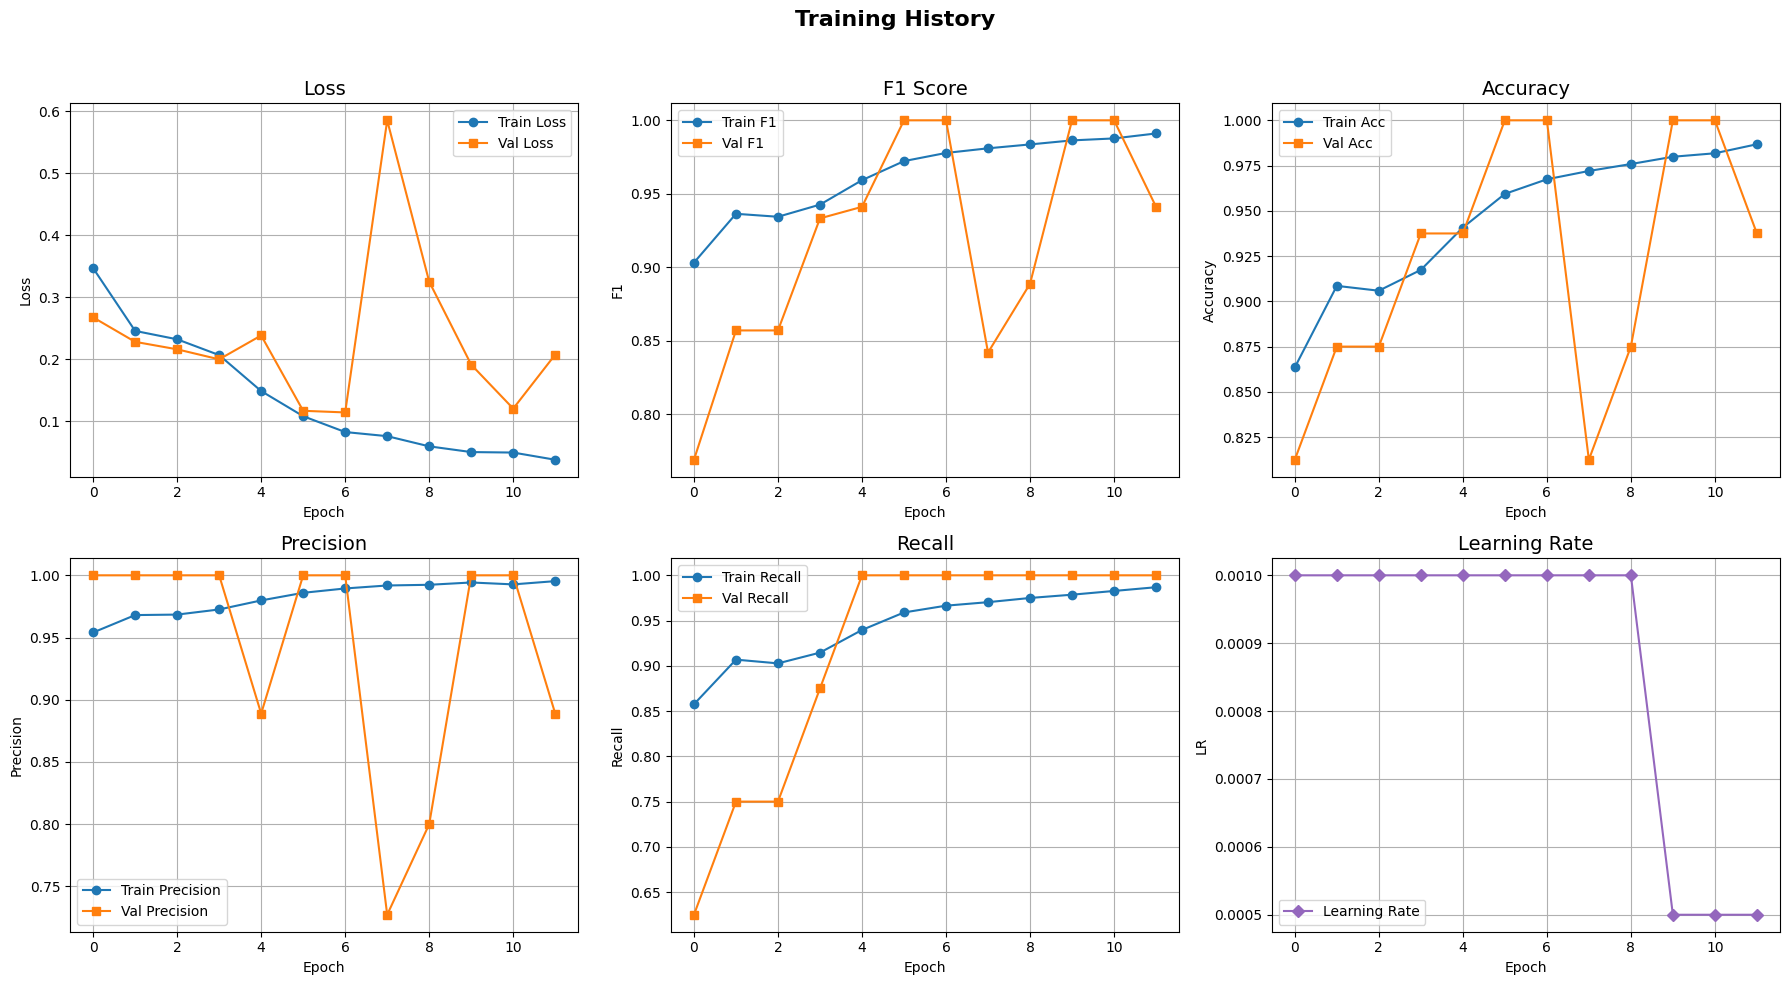

訓練曲線已更新: outputs/training_curves.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt

def plot_history(history, output_dir):
    """根據目前累積的 history 繪製訓練曲線並儲存到 output_dir。"""
    epochs = [h["epoch"] for h in history]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    # --- 1. Loss (train + val) ---
    ax = axes[0, 0]
    ax.plot(epochs, [h["train_loss"] for h in history], marker="o", label="Train Loss")
    ax.plot(epochs, [h["val_loss"] for h in history], marker="s", label="Val Loss")
    ax.set_title("Loss", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)

    # --- 2. F1 (train + val) ---
    ax = axes[0, 1]
    ax.plot(epochs, [h["train_f1"] for h in history], marker="o", label="Train F1")
    ax.plot(epochs, [h["val_f1"] for h in history], marker="s", label="Val F1")
    ax.set_title("F1 Score", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("F1")
    ax.legend()
    ax.grid(True)

    # --- 3. Accuracy (train + val) ---
    ax = axes[0, 2]
    ax.plot(epochs, [h["train_acc"] for h in history], marker="o", label="Train Acc")
    ax.plot(epochs, [h["val_acc"] for h in history], marker="s", label="Val Acc")
    ax.set_title("Accuracy", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
    ax.legend()
    ax.grid(True)

    # --- 4. Precision (train + val) ---
    ax = axes[1, 0]
    ax.plot(epochs, [h["train_precision"] for h in history], marker="o", label="Train Precision")
    ax.plot(epochs, [h["val_precision"] for h in history], marker="s", label="Val Precision")
    ax.set_title("Precision", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Precision")
    ax.legend()
    ax.grid(True)

    # --- 5. Recall (train + val) ---
    ax = axes[1, 1]
    ax.plot(epochs, [h["train_recall"] for h in history], marker="o", label="Train Recall")
    ax.plot(epochs, [h["val_recall"] for h in history], marker="s", label="Val Recall")
    ax.set_title("Recall", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Recall")
    ax.legend()
    ax.grid(True)

    # --- 6. Learning Rate ---
    ax = axes[1, 2]
    ax.plot(epochs, [h["lr"] for h in history], marker="D", color="tab:purple", label="Learning Rate")
    ax.set_title("Learning Rate", fontsize=14)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("LR")
    ax.legend()
    ax.grid(True)

    # 讓 x 軸只顯示整數 epoch
    for row in axes:
        for a in row:
            a.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

    fig.suptitle("Training History", fontsize=16, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    save_path = output_dir / "training_curves.png"
    fig.savefig(save_path, dpi=150)
    plt.show(fig)
    plt.close(fig)
    print(f"訓練曲線已更新: {save_path}")

plot_history(history, output_dir)

* 根據訓練曲線寫改進規劃(驗證集過少)
* Grad-Cam
* 是否換回 ResNet50，以及原因

In [ ]:
print(
    f"""
          |  Loss  |   F1   |  Acc   | Precision | Recall |
    Train | 0.1234 | 0.1234 | 0.1234 |  0.1234   | 0.1234 |
    Val   | 0.1234 | 0.1234 | 0.1234 |  0.1234   | 0.1234 |
    """
)


          |  Loss  |   F1   |  Acc   | Precision | Recall |
    Train | 0.1234 | 0.1234 | 0.1234 |  0.1234   | 0.1234 |
    Val   | 0.1234 | 0.1234 | 0.1234 |  0.1234   | 0.1234 |
    


In [ ]:
output_dir = Path("output2")
output_dir.mkdir(parents=True, exist_ok=True)